# imports

In [ ]:
%load_ext autoreload
%autoreload 2

import re
import os
import sys
import random
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from tqdm import tqdm
from glob import glob

sys.path.append("../src/")
# sys.path.append("../src/multiblimp/")


from multiblimp.languages import get_ud_langs

from word_order.process_treebank import load_treebank, create_word_order_df, read_df
from word_order.create_pairs import create_pairs
from word_order.prediction_target import *

import numpy as np

import pandas as pd


random.seed(42)

target = nsubj_target

deprel_dir = "_".join(target.child_deprels)
resource_dir = "../resources"
word_order_dir = f"../treebank_features/{deprel_dir}"

# langs = get_ud_langs(resource_dir)
langs = ["Dutch"]

max_treebank_len =  30000

for lang in tqdm(sorted(langs)):
    if not os.path.exists(f"{word_order_dir}/{lang.replace(' ', '_')}.csv"):
        treebank = load_treebank(lang, resource_dir, max_treebank_len=max_treebank_len)

        # mode must still be head_child (as opposed to multi_child)
        df = create_word_order_df(
            lang=lang, 
            treebank=treebank,
            target=target, 
            resource_dir=resource_dir,
            save_to=word_order_dir,
            max_treebank_len=max_treebank_len,
            drop_singleton_columns=True,
        )

        print(lang, len(df))
        #/Users/jacobleesuchardt/projects/multiblimp-sva-dt/resources/ud/ud_pickles/German.pickle
    else:
        print("skipping", lang)


# from word_order.decision_tree import fit_dt
# import math
# from word_order.viz_tree import tree2html


# def get_impurity(n, min_n=300, max_n=4000, max_val=0.1, min_val=0.01):
#     if n <= min_n:
#         return max_val
#     if n >= max_n:
#         return min_val

#     t = (math.log(n) - math.log(min_n)) / (math.log(max_n) - math.log(min_n))
    
#     return max_val - t * (max_val - min_val)
    

# langs = [path.split('/')[-1].split('.')[0] for path in glob(word_order_dir+"/*.csv")]

# deprels = ['nsubj']

# dt_df_dir = "../dt_df/"

# # all_base_entropy = []
# # all_model_entropy = []

# predictor_var = f"head_nsubj_Number_agreement"
# tofeat= {"Number": "#", "Gender": "G", "Case": "G"}

# targetfeat=f"sv{tofeat[predictor_var.split("_")[2]]}a"




# for lang in tqdm(sorted(langs), total=len(langs)):
#     html_file = f"sva/decision_trees/html/{targetfeat}/{lang}.html"
#     if not os.path.exists(html_file):
       
#     # if os.path.exists(html_file):
#     #     continue

#         print(lang)
#         treebank = load_treebank(lang, resource_dir, max_treebank_len=max_treebank_len)
#         raw_df = read_df(lang, word_order_dir=word_order_dir)

#         full_df = raw_df[raw_df[predictor_var].notnull()]

#         if len(full_df) == 0:
#             continue

#         # full_df = full_df[full_df[predictor_var].str.len() == 3] # specific vor svo?
#         # full_df = full_df[full_df['head_deprel'] == 'root'] # sva specific?

#         ## idk
#         # if 'child_sibling-deprel_aux' in full_df.columns:
#         #     full_df = full_df[~full_df['child_sibling-deprel_aux']]
#         # if 'child_sibling-deprel_cop' in full_df.columns:
#         #     full_df = full_df[~full_df['child_sibling-deprel_cop']]

#         omit_feats = None #{col for col in full_df.columns if ('nsubj' in col) or ('obj' in col) or ('form' in col) or ('lemma' in col)}

#         min_impurity_decrease = get_impurity(len(full_df))

#         for deprel in deprels:
#             model, dt_df, predictor_df = fit_dt(
#                 full_df, 
#                 target, 
#                 verbose=1, 
#                 predictor_var=predictor_var,
#                 min_impurity_decrease=min_impurity_decrease,
#                 min_samples_leaf=10,
#                 save_to=f"sva/decision_trees/{targetfeat}_{deprel}/{lang}",
#                 omit_feats=omit_feats,
#             )

#             if model is None:
#                 print("skipping", lang)
#                 continue
        
#             # ????
#             # swap_df = create_pairs(
#             #     model, 
#             #     dt_df,
#             #     full_df, 
#             #     treebank, 
#             #     predictor_var,
#             #     swap_type="core_arg",
#             #     # save_to_tight_keep=f"word_order/pairs/tight/{deprel}/{lang}.csv",
#             #     # save_to_full_keep=f"word_order/pairs/full/{deprel}/{lang}.csv",
#             #     save_to=os.path.join(dt_df_dir, f"{lang}.csv"),
#             # )
#             #tree2html(model, dt_df, full_df, predictor_var, html_file, max_rows=15)

#             tree2html(
#             model, 
#             dt_df, 
#             full_df, 
#             predictor_var,
#             target,
#             html_file, 
#             max_rows=15,
#             meta={"Language": lang},
#             only_show_real_orders=True,
#             correlate_features=True,
#         )

            
#             # plot_dt(
#             #     model, 
#             #     # save_to=f"word_order/decision_trees/{deprel}/{lang}.pdf", 
#             #     show_plot=True
#             # )
        
#             # deprel_entropy = calc_dep_entropy(full_df)
#             # base_entropy = deprel_entropy[deprel]
#             # model_entropy = calc_model_entropy(model, dt_df)
        
#             # all_base_entropy.append(base_entropy)
#             # all_model_entropy.append(model_entropy)
#     else:
#         print("skipping", lang)

# # generate_html_index('word_order/decision_trees/html/')

100%|██████████| 1/1 [00:00<00:00, 1516.93it/s]

skipping Dutch


In [2]:
lang="Dutch"
tb = load_treebank(lang, resource_dir, max_treebank_len=max_treebank_len)
# full_df = raw_df[raw_df[predictor_var].notnull()]

In [3]:
# for dutch: is person ever tagged?
verb_feats = set()
verb_lemmas = {}
v_form_feats = {}

for sent in tb:
    has_person = [x for x in sent if x.get('feats', False) and 'Person' in x['feats']]
    verb_has_person = [x for x in sent if x.get('feats', False) and 'Person' in x['feats'] and x['upos']=='VERB']
    if len(verb_has_person): print(verb_has_person)
    for x in [x for x in sent if x['upos']=='VERB' and x.get('feats', False)]:
        v_form_feats[x['lemma']] = v_form_feats.get(x['lemma'], dict())
        v_form_feats[x['lemma']]['n'] = v_form_feats[x['lemma']].get('n', 0)+1
        form_feats = "|".join([f"{k}={v}" for k, v in (x['feats'].items())])
        v_form_feats[x['lemma']][form_feats] = v_form_feats[x['lemma']].get(form_feats, dict())
        v_form_feats[x['lemma']][form_feats][x['form'].lower()] =  v_form_feats[x['lemma']][form_feats].get(x['form'].lower(), 0) +1
        # prons = [(y['form'], y['upos'], y['feats'], y['deprel']) for y in sent if y['head']==x['id'] and y['deprel'] in ["nsubj"]]
        # if prons:
        #     print(x['form'], x['feats'])
        #     for z in prons:
        #         print('\t', z)
        #     print()
        # #verb_feats.update(set([(feat, val) for feat, val in x['feats'].items()]))
        # verb_lemmas[x['lemma']] = verb_lemmas.get(x['lemma'], 0)+1
    #if len(has_person)>1 and any([x for x in has_person if x['feats']['Person'] in ["2", 2]]):
        # print([(x['feats']['Person'], x['upos']) for x in has_person])
    # for x in sent:
    #     if x.get('feats', False) and 'Person' in x['feats']:
    #         print([x])
    # break
#sorted(verb_lemmas.items(), key= lambda x: x[1], reverse=True)
v_form_feats

{'mee_nemen': {'n': 27,
  'VerbForm=Part': {'meegenomen': 4},
  'VerbForm=Inf': {'nemen': 6, 'meenemen': 3},
  'Mood=Ind|Number=Sing|Tense=Past|VerbForm=Fin': {'meenam': 2, 'nam': 1},
  'Mood=Ind|Number=Plur|Tense=Past|VerbForm=Fin': {'namen': 2},
  'Mood=Ind|Number=Sing|Tense=Pres|VerbForm=Fin': {'neemt': 5},
  'Mood=Ind|Number=Plur|Tense=Pres|VerbForm=Fin': {'nemen': 3, 'meenemen': 1}},
 'blijken': {'n': 217,
  'VerbForm=Inf': {'blijken': 15},
  'Mood=Ind|Number=Sing|Tense=Pres|VerbForm=Fin': {'blijkt': 79},
  'Mood=Ind|Number=Plur|Tense=Past|VerbForm=Fin': {'bleken': 12},
  'Mood=Ind|Number=Sing|Tense=Past|VerbForm=Fin': {'bleek': 94},
  'VerbForm=Part': {'gebleken': 11},
  'Mood=Ind|Number=Plur|Tense=Pres|VerbForm=Fin': {'blijken': 6}},
 'tegen_vallen': {'n': 4,
  'Mood=Ind|Number=Sing|Tense=Pres|VerbForm=Fin': {'tegenvalt': 1},
  'Mood=Ind|Number=Plur|Tense=Past|VerbForm=Fin': {'tegenvielen': 1},
  'Mood=Ind|Number=Sing|Tense=Past|VerbForm=Fin': {'viel': 1},
  'VerbForm=Part': {'t

In [4]:
v_sort = dict(sorted(v_form_feats.items(), key=lambda x: x[1]['n'], reverse=True))
import json 

# with open (f"../{lang}_verbfeats2forms.json", "w") as f:
#     json.dump(v_sort, f)

In [5]:
from multiblimp.unimorph import UnimorphInflector, allval2um, UNDEFINED
from multiblimp.languages import (
    lang2langcode,
    remove_diacritics_langs,
    remove_multiples_langs,
    gblang2udlang,
    lang2unimorph_lang,
)
def load_inflector(lang: str, langcode: str, unimorph_args):
        num_form = 0
        num_lemma = 0
        skip_lang = False

        remove_diacritics = lang in remove_diacritics_langs
        remove_multiples = lang in remove_multiples_langs

        inflector = UnimorphInflector(
            langcode,
            ("Person", None), # swap_any_person
            resource_dir=resource_dir,
            load_from_pickle=True,
            remove_diacritics=remove_diacritics,
            remove_multiples=remove_multiples,
            **unimorph_args,
        )

        if len(inflector) == 0:
            skip_lang = True
            num_lemma = 0
            num_form = 0
        else:
            num_lemma = inflector.num_lemmas
            num_form = inflector.num_forms

        if not inflector.can_feature_swap:
            skip_lang = True

        return inflector, skip_lang, num_lemma, num_form


inflector, skip_lang, num_lemma, num_form = load_inflector(
            lang=lang, langcode="nld", unimorph_args={
            "filter_entries": {
                "upos": ["V"],
            },
            "combine_um_ud": True,
            "remove_multiword_forms": True,
        },
        )

In [6]:
c=0
smd = dict()
for i, x in enumerate(v_sort):
    smd[x] = smd.get(x, dict())
    for feats, y in v_sort[x].items():
        if type(y)==dict and len(y)>1:
            for form in y:
                ret = inflector.get_form_features(form,
                            features = {a.split('=')[0]: a.split('=')[1] for a in feats.split('|')},
                             only_try_ud_if_no_um=True)
                #if form in list(inflector.unimorph_df['form']):
                   # print(inflector.unimorph_df[inflector.unimorph_df['form']==form])
                smd[x][feats] = smd[x].get(feats, dict())
                smd[x][feats][f"+{tuple(ret)}"] = smd[x][feats].get(f"+{tuple(ret)}", list()) + [form,]
            

    if smd[x] == {}: del smd[x]
with open(f"notes/{lang}_ambigvfeats_reduced.json", "w") as f:
    json.dump(smd, f)

In [7]:
smd

{'hebben': {'Mood=Ind|Number=Sing|Tense=Pres|VerbForm=Fin': {"+('3',)": ['heeft'],
   "+('1',)": ['heb'],
   "+('2',)": ['hebt'],
   '+()': ['hebbe']},
  'VerbForm=Part': {"+('UNDEFINED',)": ['gehad'], '+()': ['hebbende']}},
 'komen': {'VerbForm=Part': {'+()': ['komende', 'gekomen', 'komend']},
  'Mood=Ind|Number=Plur|Tense=Past|VerbForm=Fin': {"+('UNDEFINED',)": ['kwamen'],
   '+()': ['kwamer']},
  'Mood=Ind|Number=Sing|Tense=Pres|VerbForm=Fin': {"+('3', '2')": ['komt'],
   "+('1',)": ['kom'],
   '+()': ['kome']}},
 'zijn': {'Mood=Ind|Number=Sing|Tense=Pres|VerbForm=Fin': {'+()': ['is',
    'zij',
    'ware',
    'ben',
    'bent']},
  'VerbForm=Part': {'+()': ['geweest', 'zijnde', 'gewezen']},
  'VerbForm=Inf': {'+()': ['zijn', 'wezen']}},
 'worden': {'Mood=Ind|Number=Sing|Tense=Pres|VerbForm=Fin': {'+()': ['wordt',
    'word']},
  'VerbForm=Part': {'+()': ['geworden', 'wordende']}},
 'gaan': {'Mood=Ind|Number=Sing|Tense=Pres|VerbForm=Fin': {'+()': ['gaat',
    'ga']},
  'VerbForm=Pa

In [221]:
for a in [x for i, x in enumerate(v_sort) if any([len(y)>1 if type(y)==dict else 0 for y in v_sort[i][1].values()])]:
    for b in a:
        print(b)
    break
b

KeyError: 0

In [237]:
from multiblimp.unimorph import UnimorphInflector, allval2um, UNDEFINED
from multiblimp.languages import (
    lang2langcode,
    remove_diacritics_langs,
    remove_multiples_langs,
    gblang2udlang,
    lang2unimorph_lang,
)
def load_inflector(lang: str, langcode: str, unimorph_args):
        num_form = 0
        num_lemma = 0
        skip_lang = False

        remove_diacritics = lang in remove_diacritics_langs
        remove_multiples = lang in remove_multiples_langs

        inflector = UnimorphInflector(
            langcode,
            ("Person", None), # swap_any_person
            resource_dir=resource_dir,
            load_from_pickle=True,
            remove_diacritics=remove_diacritics,
            remove_multiples=remove_multiples,
            **unimorph_args,
        )

        if len(inflector) == 0:
            skip_lang = True
            num_lemma = 0
            num_form = 0
        else:
            num_lemma = inflector.num_lemmas
            num_form = inflector.num_forms

        if not inflector.can_feature_swap:
            skip_lang = True

        return inflector, skip_lang, num_lemma, num_form


inflector, skip_lang, num_lemma, num_form = load_inflector(
            lang=lang, langcode="nld", unimorph_args={
            "filter_entries": {
                "upos": ["V"],
            },
            "combine_um_ud": True,
            "remove_multiword_forms": True,
        },
        )

In [249]:
inflector.get_form_features("hebt",
                            features = {},
                            #{a.split('=')[0]: a.split('=')[1] for a in "Mood=Ind|Number=Sing|Tense=Pres|VerbForm=Fin".split('|')},
                             only_try_ud_if_no_um=True)


{'2', 'UNDEFINED'}

In [246]:
n=0
for lemma, sd in smd.items():
    for form in [x for y in sd.values() for x in y]:
        print(form)
        if form in list(inflector.unimorph_df['form']):
            print(inflector.unimorph_df[inflector.unimorph_df['form']==form])
            n+=1
        else:
            pass
n

heeft
        lemma   form           ufeat Finiteness Mood Number upos VerbForm  \
18507  hebben  heeft  V;IND;PRS;3;SG        NaN  IND     SG    V      NaN   

      Person Tense  
18507      3   PRS  
heb
        lemma form           ufeat Finiteness Mood Number upos VerbForm  \
18505  hebben  heb        V;IMP;SG        NaN  IMP     SG    V      NaN   
18506  hebben  heb  V;IND;PRS;1;SG        NaN  IND     SG    V      NaN   

          Person Tense  
18505  UNDEFINED   NaN  
18506          1   PRS  
hebt
        lemma  form           ufeat Finiteness Mood Number upos VerbForm  \
18503  hebben  hebt        V;IMP;PL        NaN  IMP     PL    V      NaN   
18504  hebben  hebt  V;IND;PRS;2;SG        NaN  IND     SG    V      NaN   

          Person Tense  
18503  UNDEFINED   NaN  
18504          2   PRS  
hebbe
        lemma   form          ufeat Finiteness  Mood Number upos VerbForm  \
18502  hebben  hebbe  V;SBJV;PRS;SG        NaN  SBJV     SG    V      NaN   

          Person Tense

801

In [243]:
inflector.unimorph_df[inflector.unimorph_df['form']==inflector.unimorph_df['form'].iloc[0]]

,lemma,form,ufeat,Finiteness,Mood,Number,upos,VerbForm,Person,Tense
54,aanbidden,aanbaden,V;IND;PST;PL,NaN,IND,PL,V,NaN,UNDEFINED,PST
55,aanbidden,aanbaden,V;SBJV;PST;PL,NaN,SBJV,PL,V,NaN,UNDEFINED,PST


In [241]:
# inflector.unimorph_df[inflector.unimorph_df['form'].startswith("hee")]#[inflector.unimorph_df['form']=='heeft']
[x for x in list(inflector.unimorph_df['form']) if x.startswith("he")]

['hebben',
 'hebben',
 'hebben',
 'hebbe',
 'hebt',
 'hebt',
 'heb',
 'heb',
 'heeft',
 'hechten',
 'hechten',
 'hechten',
 'hechte',
 'hechtten',
 'hechtten',
 'hechtte',
 'hechtte',
 'hechtte',
 'hechtte',
 'hecht',
 'hecht',
 'hecht',
 'hecht',
 'hecht',
 'heersen',
 'heersen',
 'heersen',
 'heerse',
 'heersten',
 'heersten',
 'heerste',
 'heerste',
 'heerste',
 'heerste',
 'heerst',
 'heerst',
 'heerst',
 'heers',
 'heers',
 'heffen',
 'heffen',
 'heffen',
 'heffe',
 'heft',
 'heft',
 'heft',
 'hef',
 'hef',
 'heiligden',
 'heiligden',
 'heiligde',
 'heiligde',
 'heiligde',
 'heiligde',
 'heiligen',
 'heiligen',
 'heiligen',
 'heilige',
 'heiligt',
 'heiligt',
 'heiligt',
 'heilig',
 'heilig',
 'helden',
 'helden',
 'helde',
 'helde',
 'helde',
 'helde',
 'hellen',
 'hellen',
 'hellen',
 'helle',
 'helt',
 'helt',
 'helt',
 'hel',
 'hel',
 'helpen',
 'helpen',
 'helpen',
 'helpe',
 'helpt',
 'helpt',
 'helpt',
 'help',
 'help',
 'hengelden',
 'hengelden',
 'hengelde',
 'hengelde',


In [186]:
{a.split('=')[0]: a.split('=')[1] for a in "Mood=Ind|Number=Sing|Tense=Pres|VerbForm=Fin".split('|')}

{'Mood': 'Ind', 'Number': 'Sing', 'Tense': 'Pres', 'VerbForm': 'Fin'}

In [ ]:
,# for i, x in enumerate(v_sort):
#     print(x)
#     print([len(y) if for y in x[1].values()])
#     break
print(len([x for i, x in enumerate(v_sort) if any([len(y)>1 if type(y)==dict else 0 for y in v_sort[i][1].values()])]))

994


In [135]:
v_sort

{'hebben': {'n': 1243,
  'Mood=Ind|Number=Plur|Tense=Pres|VerbForm=Fin': {'hebben': 191},
  'Mood=Ind|Number=Sing|Tense=Pres|VerbForm=Fin': {'heeft': 423,
   'heb': 52,
   'hebt': 12,
   'hebbe': 1},
  'Mood=Ind|Number=Sing|Tense=Past|VerbForm=Fin': {'had': 279},
  'Mood=Ind|Number=Plur|Tense=Past|VerbForm=Fin': {'hadden': 130},
  'VerbForm=Part': {'gehad': 62, 'hebbende': 1},
  'VerbForm=Inf': {'hebben': 91},
  'Mood=Imp|Number=Sing|Tense=Pres|VerbForm=Fin': {'heb': 1}},
 'komen': {'n': 1126,
  'VerbForm=Part': {'komende': 47, 'gekomen': 79, 'komend': 3},
  'Mood=Ind|Number=Plur|Tense=Past|VerbForm=Fin': {'kwamen': 93, 'kwamer': 1},
  'VerbForm=Inf': {'komen': 193},
  'Mood=Ind|Number=Plur|Tense=Pres|VerbForm=Fin': {'komen': 64},
  'Mood=Ind|Number=Sing|Tense=Pres|VerbForm=Fin': {'komt': 286,
   'kom': 20,
   'kome': 2},
  'Mood=Ind|Number=Sing|Tense=Past|VerbForm=Fin': {'kwam': 333},
  'Mood=Imp|Number=Sing|Tense=Pres|VerbForm=Fin': {'kom': 5}},
 'zijn': {'n': 1018,
  'Mood=Ind|Numbe

In [ ]:
for lemma in v_form_feats:
    for form in v_form_feats['l']

In [53]:
sorted(verb_lemmas.items(), key= lambda x: x[1], reverse=True)

[('hebben', 1243),
 ('komen', 1126),
 ('zijn', 1018),
 ('worden', 796),
 ('gaan', 777),
 ('maken', 653),
 ('zien', 650),
 ('willen', 590),
 ('krijgen', 510),
 ('doen', 471),
 ('zeggen', 467),
 ('noemen', 445),
 ('staan', 444),
 ('blijven', 398),
 ('geven', 393),
 ('laten', 372),
 ('vinden', 360),
 ('liggen', 356),
 ('houden', 352),
 ('beginnen', 330),
 ('weten', 318),
 ('volgen', 312),
 ('bestaan', 307),
 ('heten', 302),
 ('nemen', 284),
 ('brengen', 251),
 ('winnen', 223),
 ('spelen', 221),
 ('blijken', 217),
 ('stellen', 210),
 ('gebruiken', 207),
 ('ontstaan', 207),
 ('leiden', 196),
 ('vormen', 192),
 ('zitten', 189),
 ('vallen', 189),
 ('werken', 180),
 ('denken', 179),
 ('verliezen', 174),
 ('vragen', 172),
 ('lijken', 160),
 ('lopen', 158),
 ('plaats_vinden', 147),
 ('schrijven', 146),
 ('besluiten', 146),
 ('proberen', 144),
 ('bepalen', 143),
 ('bereiken', 128),
 ('gebeuren', 126),
 ('vertrekken', 126),
 ('op_richten', 121),
 ('verschijnen', 116),
 ('spreken', 116),
 ('kennen'

In [3]:
df

,sen,treebank,deprel_order,tree_idx,head_nsubj_Gender_agreement,head_nsubj_Case_agreement,sent_id,head_nsubj_Number_agreement,core_args,head_Number,...,nsubj_under_ccomp,nsubj_under_compound,nsubj_under_conj,nsubj_under_nmod,nsubj_under_obj,nsubj_under_obl,nsubj_under_xcomp,object_idx,subject_idx,verb_idx
0,"[Der, Vertrag, läuft, offiziell, bis, zu, dem,...",UD_German-GSD,sV,1,False,False,train-s1871,True,sv,Sing,...,False,False,False,False,False,False,False,NaN,2.0,3.0
1,"[Zu, dem, Schluß, gibt, es, sogar, noch, typis...",UD_German-GSD,Vs,2,False,False,train-s419,True,vso,Sing,...,False,False,False,False,False,False,False,10.0,5.0,4.0
2,"[Ebenso, mit, in, das, Grab, nahm, sie, ihr, w...",UD_German-GSD,Vs,5,False,False,train-s4194,True,vso,Sing,...,False,False,False,False,False,False,False,10.0,7.0,6.0
3,"[Ebenso, mit, in, das, Grab, nahm, sie, ihr, w...",UD_German-GSD,sV,5,False,False,train-s4194,False,vso,NaN,...,False,False,False,False,True,False,False,10.0,7.0,6.0
4,"[Der, Photoschutz, -, Mechanismus, der, DNA, h...",UD_German-GSD,sV,8,False,False,train-s13063,False,sov,NaN,...,False,False,False,False,False,False,False,8.0,4.0,15.0
5,"[CDU, -, Fraktionschef, Roland, Koch, ,, der, ...",UD_German-GSD,sV,9,False,False,train-s1725,True,svo,Sing,...,False,False,False,False,False,False,False,24.0,3.0,20.0
6,"[CDU, -, Fraktionschef, Roland, Koch, ,, der, ...",UD_German-GSD,sV,9,False,False,train-s1725,False,svo,NaN,...,False,True,False,False,False,False,False,24.0,3.0,20.0
7,"[Sie, näherten, sich, dabei, dem, irrationalen...",UD_German-GSD,sV,11,True,False,train-s13138,True,sv,Plur,...,False,False,False,False,False,False,False,NaN,1.0,2.0
8,"[Sie, näherten, sich, dabei, dem, irrationalen...",UD_German-GSD,sV,11,True,False,train-s13138,False,sv,NaN,...,False,False,False,False,False,False,False,NaN,1.0,2.0
9,"[Sie, näherten, sich, dabei, dem, irrationalen...",UD_German-GSD,sV,11,True,False,train-s13138,False,sv,NaN,...,False,False,False,False,False,False,False,NaN,1.0,2.0


In [4]:
[col for col in df.columns if "head_child-deprel_nsubj" in col]


[]

In [5]:
print(list(df.columns))

['sen', 'treebank', 'deprel_order', 'tree_idx', 'head_nsubj_Gender_agreement', 'head_nsubj_Case_agreement', 'sent_id', 'head_nsubj_Number_agreement', 'core_args', 'head_Number', 'head_Person', 'head_Tense', 'head_VerbForm', 'head_child-deprel_advcl', 'head_child-deprel_advmod', 'head_child-deprel_amod', 'head_child-deprel_aux', 'head_child-deprel_cc', 'head_child-deprel_compound:prt', 'head_child-deprel_conj', 'head_child-deprel_expl:pv', 'head_child-deprel_mark', 'head_child-deprel_obj', 'head_child-deprel_obl', 'head_child-deprel_obl:arg', 'head_child-deprel_punct', 'head_child-deprel_xcomp', 'head_child-feat_advcl_VerbForm', 'head_child-feat_advmod_PronType', 'head_child-feat_aux_Number', 'head_child-feat_aux_Person', 'head_child-feat_aux_Tense', 'head_child-feat_obj_Case', 'head_child-feat_obj_Gender', 'head_child-feat_obj_Number', 'head_child-feat_obj_PronType', 'head_child-feat_obl:arg_Gender', 'head_child-feat_obl_Case', 'head_child-feat_obl_Gender', 'head_child-feat_obl_Number'

In [10]:
ccomp = []

for tree in treebank:
    keep = False
    for tok in tree:
        if tok['deprel'] == 'ccomp':
            keep = True

    if keep:
        ccomp.append(tree)

In [12]:
ccomp

[TokenList<Voorts, zijn, er, kleine, groepen, die, België, willen, aanhechten, bij, Nederland, (, Heel-Nederlanders, ), dan, wel, bij, Frankrijk, (, rattachisme, ), dan, wel, Vlaanderen, bij, Nederland, willen, doen, aansluiten, (, Groot-Nederlanders, ), ., metadata={archive: "nl_lassysmallenhanced-ud-test.collection", source: "LassyEnhanced/wiki-135/wiki-135.p.106.s.1.xml", sent_id: "wiki-135.p.106.s.1", text: "Voorts zijn er kleine groepen die België willen aanhechten bij Nederland (Heel-Nederlanders) dan wel bij Frankrijk (rattachisme) dan wel Vlaanderen bij Nederland willen doen aansluiten (Groot-Nederlanders).", auto: "ALUD2.13.0", meta_source: "wiki", meta_type: "wiki", meta_description: "Wikipedia", treebank: "UD_Dutch-LassySmall/nl_lassysmall-ud-test.conllu"}>,
 TokenList<De, hoofdstad, Brussel, is, formeel, tweetalig, ,, maar, de, praktijk, wijst, uit, dat, de, meerderheid, van, de, bevolking, Frans, spreekt, ., metadata={archive: "nl_lassysmallenhanced-ud-test.collection", so

In [2]:
# import sys
# sys.path.append("../src/")
# from glob import glob

from word_order.decision_tree import fit_dt
import math
from word_order.viz_tree import tree2html


def get_impurity(n, min_n=300, max_n=4000, max_val=0.1, min_val=0.01):
    if n <= min_n:
        return max_val
    if n >= max_n:
        return min_val

    t = (math.log(n) - math.log(min_n)) / (math.log(max_n) - math.log(min_n))
    
    return max_val - t * (max_val - min_val)
    

langs = "German" #get_ud_langs(resource_dir)
langs = [path.split('/')[-1].split('.')[0] for path in glob(word_order_dir+"/*.csv")]
# langs = ['Afrikaans']
deprels = ['nsubj']

dt_df_dir = "../dt_df/"

all_base_entropy = []
all_model_entropy = []

predictor_var = f"head_nsubj_Number_agreement"


for lang in tqdm(sorted(langs), total=len(langs)):
    html_file = f"sva/decision_trees/html/{lang}.html"
    # if os.path.exists(html_file):
    #     continue

    print(lang)
    treebank = load_treebank(lang, resource_dir, max_treebank_len=max_treebank_len)
    raw_df = read_df(lang, word_order_dir=word_order_dir)
    
    full_df = raw_df[raw_df[predictor_var].notnull()]

    if len(full_df) == 0:
        continue

    # full_df = full_df[full_df[predictor_var].str.len() == 3] # specific vor svo?
    # full_df = full_df[full_df['head_deprel'] == 'root'] # sva specific?

    ## idk
    # if 'child_sibling-deprel_aux' in full_df.columns:
    #     full_df = full_df[~full_df['child_sibling-deprel_aux']]
    # if 'child_sibling-deprel_cop' in full_df.columns:
    #     full_df = full_df[~full_df['child_sibling-deprel_cop']]

    omit_feats = None #{col for col in full_df.columns if ('nsubj' in col) or ('obj' in col) or ('form' in col) or ('lemma' in col)}

    min_impurity_decrease = get_impurity(len(full_df))
    
    for deprel in deprels:
        model, dt_df, predictor_df = fit_dt(
            full_df, 
            target, 
            verbose=1, 
            predictor_var=predictor_var,
            min_impurity_decrease=min_impurity_decrease,
            min_samples_leaf=10,
            save_to=f"sva/decision_trees/sva#a_{deprel}/{lang}",
            omit_feats=omit_feats,
        )
    
        if model is None:
            print("skipping", lang)
            continue
        
        # ????
        # swap_df = create_pairs(
        #     model, 
        #     dt_df,
        #     full_df, 
        #     treebank, 
        #     predictor_var,
        #     swap_type="core_arg",
        #     # save_to_tight_keep=f"word_order/pairs/tight/{deprel}/{lang}.csv",
        #     # save_to_full_keep=f"word_order/pairs/full/{deprel}/{lang}.csv",
        #     save_to=os.path.join(dt_df_dir, f"{lang}.csv"),
        # )
        #tree2html(model, dt_df, full_df, predictor_var, html_file, max_rows=15)

        tree2html(
        model, 
        dt_df, 
        full_df, 
        predictor_var,
        target,
        html_file, 
        max_rows=15,
        meta={"Language": lang},
        only_show_real_orders=True,
        correlate_features=True,
    )

        
        # plot_dt(
        #     model, 
        #     # save_to=f"word_order/decision_trees/{deprel}/{lang}.pdf", 
        #     show_plot=True
        # )
    
        # deprel_entropy = calc_dep_entropy(full_df)
        # base_entropy = deprel_entropy[deprel]
        # model_entropy = calc_model_entropy(model, dt_df)
    
        # all_base_entropy.append(base_entropy)
        # all_model_entropy.append(model_entropy)

# generate_html_index('word_order/decision_trees/html/')

  0%|          | 0/1 [00:00<?, ?it/s]

German


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [1, 4, 8, 9, 10, 12, 20, 38, 42, 43, 46, 50, 56, 59, 63, 68, 71, 73, 77, 79, 87, 88, 89, 106, 115, 117, 119, 120, 121, 124, 126, 134, 136, 148, 149, 150] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
  0%|          | 0/1 [00:00<?, ?it/s]

Train acc 0.8333333333333334
Test acc  0.8
[np.False_, np.True_] <class 'list'>


TypeError: sequence item 0: expected str instance, numpy.bool found

In [47]:
len(full_df)

4985

In [97]:
from word_order.viz_tree import generate_html_index


generate_html_index('word_order/decision_trees/html/')

In [174]:
from word_order.viz_tree import tree2html


print(lang)
# lang = "Ancient Greek"
html_file = f"word_order/decision_trees/html/{lang}.html"
tree2html(model, dt_df, full_df, predictor_var, html_file, max_rows=15)

Afrikaans
[3, 4, 2, 5, 1, 8, 9, 7, 10, 6, 0]
['', '', 'child_sibling-pos = PUNCT<br>child_sibling-deprel = punct<br>child_sibling-deprel-R = punct<br>', '', '', '', '', '', '', '', '']


In [164]:
langs = [path.split('/')[-1].split('.')[0] for path in glob(word_order_dir+"/*.csv")]

for lang in tqdm_notebook(sorted(langs), total=len(langs)):
    html_file = f"word_order/decision_trees/html/{lang}.html"
    # if os.path.exists(html_file):
    #     continue

    print(lang)
    treebank = load_treebank(lang, resource_dir, max_treebank_len=max_treebank_len)

    full_df = read_df(lang, word_order_dir=word_order_dir)
    full_df = full_df[full_df[predictor_var].notnull()]

    if len(full_df) == 0:
        continue

    full_df = full_df[full_df[predictor_var].str.len() == 3]
    full_df = full_df[full_df['head_deprel'] == 'root']
    if 'child_sibling-deprel_aux' in full_df.columns:
        full_df = full_df[~full_df['child_sibling-deprel_aux']]
    if 'child_sibling-deprel_cop' in full_df.columns:
        full_df = full_df[~full_df['child_sibling-deprel_cop']]

    omit_feats = {col for col in full_df.columns if ('nsubj' in col) or ('obj' in col) or ('form' in col) or ('lemma' in col)}
    
    for deprel in deprels:
        model = joblib.load(f"word_order/decision_trees/core_arg_{deprel}/{lang}.joblib")
        dt_df = pd.read_csv(f"word_order/pairs/full/{deprel}/{lang}.csv", index_col=0)

        tree2html(model, dt_df, full_df, predictor_var, html_file, max_rows=15)

/tmp/ipykernel_1434662/2015577151.py:1: TqdmDeprecationWarning:

This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`



  0%|          | 0/1 [00:00<?, ?it/s]

Dutch


ValueError: columns are missing: {'child_sibling-deprel_punct'}

In [86]:
full_df.to_csv('full_df.csv')
dt_df.to_csv('dt_df.csv')

In [376]:
from urllib.parse import quote

quote("test test")

'test%20test'

In [118]:
for s1, s2 in swap_df[['sen_str', 'swapped_sen_str']][-10:].values:
    print(s1)
    print(s2)
    print()

Vanaf 256 staken Frankische krijgers de Rijn over en werd geheel Gallia geplunderd en werden vele steden en dorpen verwoest .
Vanaf 256 Frankische krijgers staken de Rijn over en werd geheel Gallia geplunderd en werden vele steden en dorpen verwoest .

Ten westen van de Kasselpoort herkennen we de gracht , de stadsmuur en een bastion uit de eerste helft van de 17e eeuw .
Ten westen van de Kasselpoort we herkennen de gracht , de stadsmuur en een bastion uit de eerste helft van de 17e eeuw .

Met herinvoering van de dienstplicht , uitbreiding van het leger en uittreden uit de Volkenbond tastte Hitler de vechtlust van de geallieerden af , waarna hij iedere keer verkondigde slechts Duitsland te verdedigen en vrede te willen .
Met herinvoering van de dienstplicht , uitbreiding van het leger en uittreden uit de Volkenbond Hitler tastte de vechtlust van de geallieerden af , waarna hij iedere keer verkondigde slechts Duitsland te verdedigen en vrede te willen .

Deze twee jaren deed men een gr

/tmp/ipykernel_803582/1972638878.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for tree_path in tqdm_notebook(sorted(tree_paths)):


  0%|          | 0/1 [00:00<?, ?it/s]

TypeError: can only concatenate str (not "numpy.int64") to str

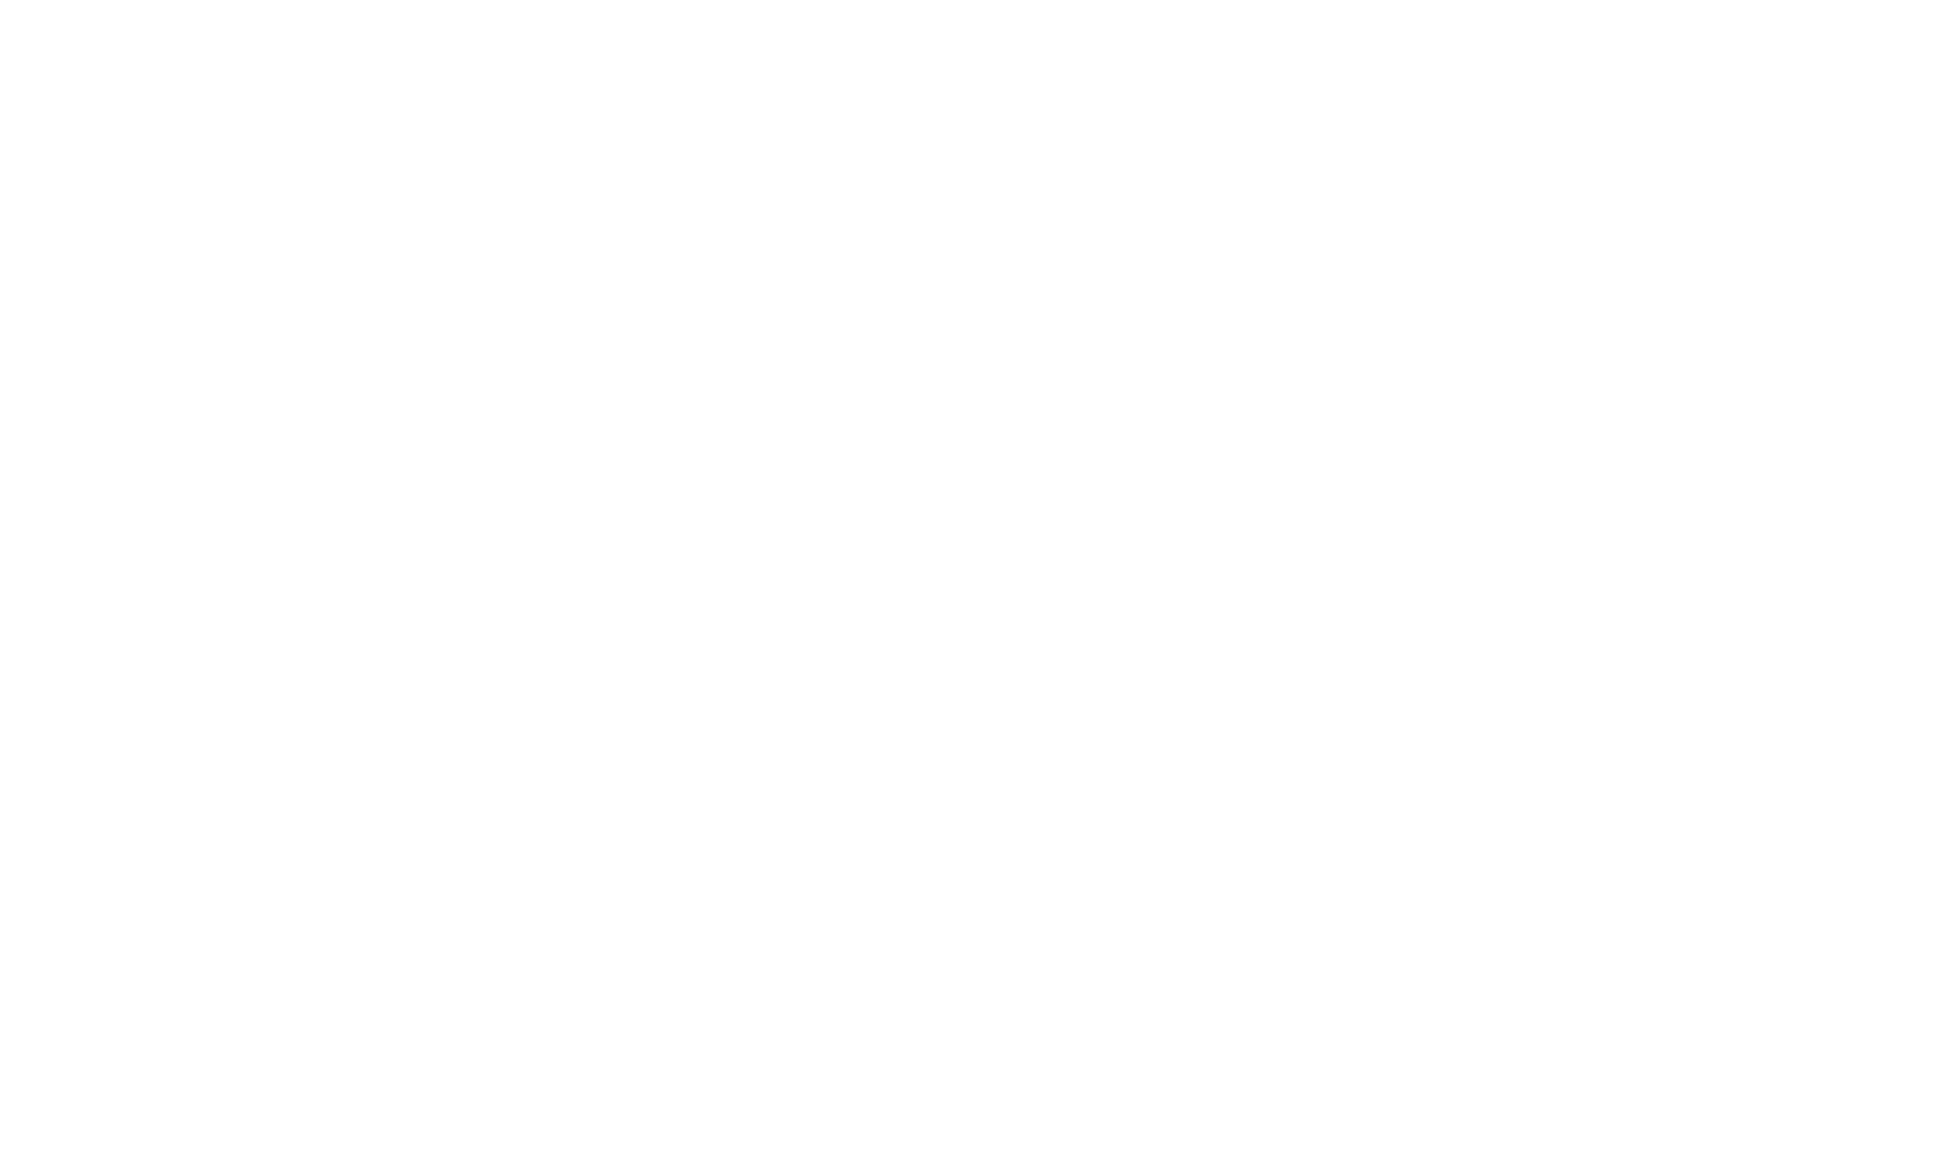

In [99]:
from glob import glob
import joblib


tree_paths = glob("word_order/decision_trees/nsubj/Dut*.joblib")

for tree_path in tqdm_notebook(sorted(tree_paths)):
    model = joblib.load(tree_path)
    lang = tree_path.split("/")[-1].split(".")[0]

    plot_dt(model, save_to=tree_path.replace("joblib", "pdf"), show_plot=True)

In [32]:
df = pd.read_csv("word_order/pairs/full/nsubj/English.csv")

df.treebank[180]

'UD_English-Atis'

In [19]:
lang2entropy = {}

langs = get_ud_langs("resources")
word_order_dir = "/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/word_order_df/"
for lang in tqdm_notebook(langs, total=len(langs)):
    if lang in lang2entropy:
        continue

    df = read_df(lang, word_order_dir=word_order_dir)

    if len(df) > 0:
        deprel_entropy = calc_dep_entropy(df)
        lang2entropy[lang] = deprel_entropy


df = pd.DataFrame.from_dict(lang2entropy, orient="index")
df.to_csv("deprel_entropy.csv")

/tmp/ipykernel_1434464/3308827709.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for lang in tqdm_notebook(langs, total=len(langs)):


  0%|          | 0/180 [00:00<?, ?it/s]

In [37]:
np.mean(all_base_entropy), np.mean(all_model_entropy), np.mean(all_base_entropy - all_model_entropy)

(np.float64(0.4854606645435053),
 np.float64(0.3071973487516613),
 np.float64(0.17826331579184387))

In [15]:
import joblib


model_fns = sorted(glob(f"word_order/decision_trees/nsubj/*.joblib"))
df_fns = sorted(glob(f"word_order/pairs/full/nsubj/*.csv"))
for model_fn, df_fn in zip(model_fns, df_fns):
    break

model = joblib.load(model_fn)
dt_df = pd.read_csv(df_fn)

model_entropy = calc_model_entropy(model, dt_df)

model_entropy

ValueError: columns are missing: {'under_ccomp', 'head_sibling-lemma_ccomp', 'child_sibling-deprel-L_amod', 'child_sibling-deprel-R_ccomp', 'head_sibling-deprel-L_dislocated', 'child_sibling-deprel_ccomp', 'head_sibling-deprel-R_dep:repeat', 'head_sibling-deprel_dep:repeat', 'head_sibling-deprel-R_obj', 'head_Gender[erg]', 'child_sibling-deprel-R_dislocated', 'under_iobj', 'child_sibling-lemma_mark', 'child_sibling-lemma_ccomp', 'head_sibling-deprel_nmod', 'head_sibling-deprel_ccomp', 'head_Gender[abs]', 'child_sibling-deprel-L_ccomp', 'head_sibling-deprel-L_nmod', 'child_Definite', 'head_Person[abs]', 'child_sibling-lemma_cc', 'head_Person[erg]', 'child_sibling-deprel-R_xcomp', 'head_Number[abs]', 'head_sibling-deprel_dislocated', 'child_sibling-pos_DET', 'child_sibling-pos_SCONJ', 'child_RelType', 'head_sibling-deprel-L_ccomp', 'head_sibling-lemma_acl', 'head_Number[erg]'}

In [17]:
df_fn, model_fn

('word_order/pairs/full/nsubj/Abkhaz.csv',
 'word_order/decision_trees/nsubj/Abaza.joblib')

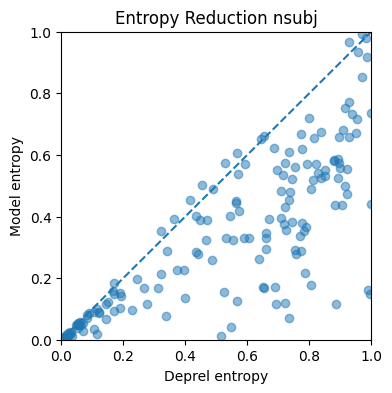

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.scatter(
    all_base_entropy,
    all_model_entropy,
    alpha=0.5,
)
plt.xlim(0,1)
plt.ylim(0,1)

plt.xlabel("Deprel entropy")
plt.ylabel("Model entropy")
plt.title(f"Entropy Reduction {deprel}")

plt.plot([0,1],[0,1],ls='--')

In [106]:
from scipy.stats import spearmanr

ent_df = pd.DataFrame.from_dict(lang2entropy).transpose()

x = 'nsubj'
y = 'obj'

df = ent_df[~ent_df[x].isna() & ~ent_df[y].isna()]
# df = df[df[y] > 0]

plt.figure(figsize=(5,5))

sns.regplot(
    data=df,
    x=x,
    y=y,
    scatter_kws={'alpha': 0.5, 'color': 'salmon'},
    # alpha=0.5,
)

plt.title("Dependency Entropy")
plt.text(0, 1, f"$r={pearsonr(df[x], df[y])[0]:.2f}$")

NameError: name 'pd' is not defined

In [78]:
# df2 = df[df.deprel == 'nsubj']

# feature = "Gender"
# feature = "Number"

# sub_df = df2[
#     (df2.child_pos == "NOUN") 
#     & (df2.head_pos == "VERB") 
#     # & (df2.head_VerbForm == "Part")
#     & (~df2[f"child_{feature}"].isna()) 
#     & (~df2[f"child_{feature}"].isna())
# ]

# sub_df['has_agr'] = sub_df[f"child_{feature}"] == sub_df[f"head_{feature}"]

# sub_df['has_agr'].mean(), len(sub_df)

In [114]:
for _, row in swap_df[:10].iterrows():
    print("+", row.sen_str)
    print("-", row.swapped_sen_str)
    print()

+ Op het programma staan een kleurenshow in Munchen , een tournee door Europa en een reisje naar Amerika in februari om te zien wat ik daar kan gaan doen . "
- Op het programma staan een kleurenshow in Munchen , een tournee door Europa en een reisje naar Amerika in februari om te zien ik daar kan gaan doen wat . "

+ Eind van het jaar 1940 moesten de Joodse mensen zich bij het bevolkingsregister laten registreren .
- Eind van het jaar 1940 moesten de Joodse mensen bij het bevolkingsregister laten registreren zich .

+ Maar begin 1863 waren opeens een aantal mensen op sleutelposities in Lee's hiërarchie omgekomen -- met name Lee's steun en toeverlaat , de excentrieke , niets-en-niemand ontziende Thomas " Stonewall " Jackson .
- Maar begin 1863 waren opeens een aantal mensen op sleutelposities in Lee's hiërarchie omgekomen -- met name Lee's steun en toeverlaat , de excentrieke , ontziende niets-en-niemand Thomas " Stonewall " Jackson .

+ Drie andere lichte geallieerde cavaleriebrigades 

# LM Eval

In [15]:
import tempfile

from tqdm import tqdm_notebook
from transformers import AutoModelForCausalLM, AutoTokenizer
from minicons import scorer
from huggingface_hub import login

import pandas as pd
import os

import dotenv

dotenv.load_dotenv()


def load_hf_model(model_name: str, no_cache=False, **kwargs):
    model = None
    tokenizer = None
    token = os.environ["HF_TOKEN"]
    kwargs["token"] = token

    login(token)

    try:
        if no_cache:
            with tempfile.TemporaryDirectory() as tmpdirname:
                model = AutoModelForCausalLM.from_pretrained(
                    model_name, cache_dir=tmpdirname, **kwargs
                )
                tokenizer = AutoTokenizer.from_pretrained(
                    model_name, cache_dir=tmpdirname, **kwargs
                )
        else:
            model = AutoModelForCausalLM.from_pretrained(model_name, **kwargs)
            tokenizer = AutoTokenizer.from_pretrained(model_name, **kwargs)
    except OSError:
        raise
        pass

    if model is None:
        return None

    ilm_model = scorer.IncrementalLMScorer(
        model,
        "cuda",
        tokenizer=tokenizer,
    )

    return ilm_model

    
def score_tse(model, tse_df, sen="sen", wrong_sen="wrong_sen", attr_prefix="", verbose=1, max_length=128):
    tse_df["sen_prob"] = pd.Series(dtype=object).astype(object)
    tse_df["wrong_prob"] = pd.Series(dtype=object).astype(object)

    iterator = tqdm_notebook(tse_df.iterrows(), total=len(tse_df)) if verbose > 0 else tse_df.iterrows()

    for idx, row in iterator:
        sen_prob, wrong_prob = score_pair(model, row[sen], row[wrong_sen], max_length)

        if sen_prob is not None:
            sen_nll = -sen_prob.sum().item()
            wrong_nll = -wrong_prob.sum().item()

            tse_df.at[idx, "sen_prob"] = sen_prob.tolist()
            tse_df.at[idx, "wrong_prob"] = wrong_prob.tolist()

            tse_df.loc[idx, "sen_nll"] = sen_nll
            tse_df.loc[idx, "wrong_nll"] = wrong_nll
            tse_df.loc[idx, "delta"] = wrong_nll - sen_nll

    tse_df = tse_df[tse_df["delta"].notna()]

    return tse_df


def score_pair(ilm_model, sen, wrong_sen, max_length):
    sen_len = len(ilm_model.tokenizer.tokenize(sen))
    wrong_sen_len = len(ilm_model.tokenizer.tokenize(wrong_sen))

    if (max_length is not None) and (
        (sen_len >= max_length) or (wrong_sen_len >= max_length)
    ):
        return None, None

    stimuli = [sen, wrong_sen]

    return ilm_model.sequence_score(stimuli, reduction=lambda x: x)


def score_cols(model, df, cols, right_col):
    for col in cols:
        df[f"{col}_prob"] = pd.Series(dtype=object).astype(object)

    for idx, row in tqdm_notebook(df.iterrows(), total=len(df)):
        sen_cols = [f"{arg}_sen_str" for arg in cols]
        stimuli = row[sen_cols]

        model_probs = model.sequence_score(stimuli, reduction=lambda x: x)

        for col, prob in zip(cols, model_probs):
            df.at[idx, f"{col}_prob"] = prob.tolist()
            df.at[idx, f"{col}_nll"] = -prob.sum().item()

        for col in cols:
            right_nll = df.loc[idx][f"{right_col}_nll"]
            wrong_nll = df.loc[idx][f"{col}_nll"]
            df.at[idx, f"{col}_delta"] = wrong_nll - right_nll

    return df

In [16]:
# llm = load_hf_model("Qwen/Qwen3-0.6B", no_cache=True)
model_name = "google/gemma-3-1b-pt"
short_model_name = model_name.split("/")[-1]
llm = load_hf_model(model_name, no_cache=False)

ConnectionError: (MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /api/whoami-v2 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7997e98f34d0>: Failed to resolve \'huggingface.co\' ([Errno -3] Temporary failure in name resolution)"))'), '(Request ID: 0a0cb29a-7a58-4e3c-8476-a3bfccea2b56)')

In [51]:
# swap_df = pd.read_csv("word_order/pairs/tight/nsubj/Dutch.csv")

keep_df = swap_df[swap_df.keep]

arg2acc = {}
arg2df = {}

core_args = ["svo", "sov", "ovs", "osv", "vso", "vos"]

for arg, arg_df in keep_df.groupby("core_args"):
    arg_df = score_cols(
        llm, 
        arg_df,
        cols=core_args,
        right_col=arg,
    )
    
    keep_df = arg_df.combine_first(keep_df)
    
    # acc = (df.delta > 0).mean()
    # print(arg, core_arg, acc)

    # arg2acc[arg, core_arg] = acc
    # arg2df[arg, core_arg] = df

/tmp/ipykernel_88240/85799861.py:95: TqdmDeprecationWarning:

This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`



  0%|          | 0/300 [00:00<?, ?it/s]

/tmp/ipykernel_88240/85799861.py:95: TqdmDeprecationWarning:

This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`



  0%|          | 0/300 [00:00<?, ?it/s]

In [35]:
n = 0
a = 0.1

for _, row in swap_df.iterrows():
    for arg in ['sov', 'svo', 'vso', 'vos', 'osv', 'ovs']:
        entropy = row[f'{arg}_entropy']
        if entropy < a:
            n += 1

n, len(swap_df)*5, sum(swap_df.keep)

(649, 1355, 0)

In [56]:
for arg, arg_df in keep_df.groupby("core_args"):
    all_correct = np.array([arg_df[f"{arg}_delta"].values for arg in core_args])
    
    print(((all_correct>=0).mean(axis=0) == 1).mean())

0.8266666666666667
0.9233333333333333


In [124]:
for core_arg in ["svo", "sov", "ovs", "osv", "vso", "vos"]:
    print(core_arg, df.iloc[100][f'{core_arg}_sen_str'], sep='\t\t')

svo		Hoe men noemt een schenking voor nuttige doeleinden ?
sov		Hoe men een schenking voor nuttige doeleinden noemt ?
ovs		Hoe een schenking voor nuttige doeleinden noemt men ?
osv		Hoe een schenking voor nuttige doeleinden men noemt ?
vso		Hoe noemt men een schenking voor nuttige doeleinden ?
vos		Hoe noemt een schenking voor nuttige doeleinden men ?


In [147]:
df[(df.delta<0)][['sen_str', 'swapped_sen_str']].values

array([['Want noch De Block , noch de Kamer weet natuurlijk het fijne van Verolme , daar heeft Cor wel voor gezorgd .',
        'Want weet noch De Block , noch de Kamer natuurlijk het fijne van Verolme , daar heeft Cor wel voor gezorgd .'],
       ['En oneindig kleine verschillen tussen getallen krijgen een betekenis ; het concept om een lijnstuk af te kunnen snijden tussen elke twee punten op de lijn wordt het concept van een reëel getal .',
        'En krijgen oneindig kleine verschillen tussen getallen een betekenis ; het concept om een lijnstuk af te kunnen snijden tussen elke twee punten op de lijn wordt het concept van een reëel getal .'],
       ["De leraar die zo'n gebeurtenis op het kind verhaalt , die mist als mens en als opvoeder iedere kwaliteit .",
        "De leraar die zo'n gebeurtenis op het kind verhaalt , mist die als mens en als opvoeder iedere kwaliteit ."],
       ['" Veg haalde het vertrouwen uit de ploeg met zijn opmerkingen over gebrek aan klasse van de spelers 

In [123]:
from glob import glob


for deprel in ["obl"]:
    files = sorted(glob(f"word_order/pairs/tight/{deprel}/*.csv"))
    
    # lang2acc = {}
    
    for fn in tqdm_notebook(files):
        score_fn = fn.replace("pairs/tight", f"model_scores/{short_model_name}")
        lang = os.path.splitext(os.path.basename(score_fn))[0]
    
        swap_df = pd.read_csv(fn)
        
        df = score_tse(llm, swap_df, sen="sen_str", wrong_sen="swapped_sen_str", verbose=0)
    
        os.makedirs(os.path.dirname(score_fn), exist_ok=True)

        df.to_csv(score_fn, index=False)
    
        acc = (df.delta > 0).mean()
    
        # lang2acc[lang] = acc
        print(lang, acc)

/tmp/ipykernel_1434464/4039515012.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for fn in tqdm_notebook(files):


  0%|          | 0/1 [00:00<?, ?it/s]

Dutch 0.9377880184331797


In [32]:
deprel_df

ents = []

for lang, acc in lang2acc.items():
    ent = deprel_df.loc[lang].nsubj

    ents.append(ent)

In [124]:
deprels = ["obl"]# ["nsubj", "obj", "iobj"]
lang2scores = defaultdict(dict)

for deprel in deprels:
    score_fns = glob(f"word_order/model_scores/gemma-3-1b-pt/{deprel}/*")

    for fn in score_fns:
        lang = os.path.splitext(os.path.basename(fn))[0]

        df = pd.read_csv(fn)
        acc = (df.delta > 0).mean()

        lang2scores[lang][deprel] = acc


Text(0.5, 0.98, 'gemma-3-1b-pt')

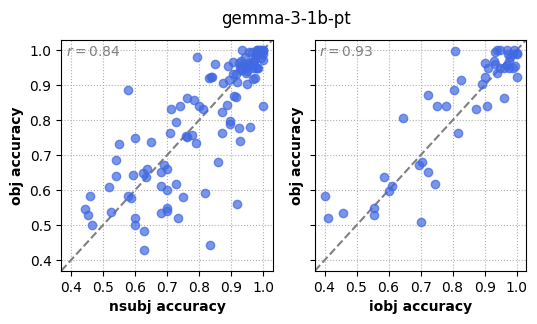

In [118]:
from scipy.stats import pearsonr


model_df = pd.DataFrame.from_dict(lang2scores, orient="index")

fig, axes = plt.subplots(1,2, figsize=(6,3), sharey=True, sharex=True)

for ax, x, y in zip(axes, ['nsubj', 'iobj'], ['obj', 'obj']):
    ax.scatter(
        data=model_df,
        x=x,
        y=y,
        zorder=10,
        color='royalblue',
        alpha=0.7,
    )
    
    xmin, xmax = 0.37, 1.03
    ax.set_ylim(xmin, xmax)
    ax.set_xlim(xmin, xmax)
    
    ax.plot([xmin, xmax], [xmin, xmax], ls='--', c='0.5')

    mask = (~model_df[x].isna()) & (~model_df[y].isna())
    corr = pearsonr(model_df[x][mask], model_df[y][mask])[0]

    ax.text(
        0.02, 0.98,
        f"$r={corr:.2f}$",
        transform=ax.transAxes,
        va="top", ha="left",
        color='0.5',
    )
    ax.set_xticks(np.arange(4,11)/10)
    ax.grid(ls=':', zorder=-10)

    ax.set_xlabel(f"{x} accuracy", fontweight='bold')
    ax.set_ylabel(f"{y} accuracy", fontweight='bold')

fig.suptitle(short_model_name)

SignificanceResult(statistic=np.float64(0.05520754026526651), pvalue=np.float64(0.5125374992075479))

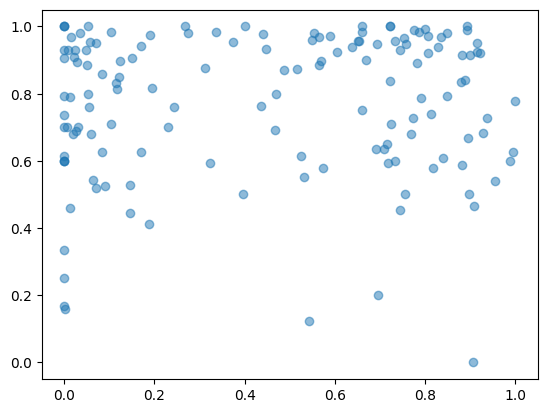

In [36]:
plt.scatter(
    ents,
    lang2acc.values(),
    alpha=0.5,
)

from scipy.stats import spearmanr

spearmanr(    
    ents,
    list(lang2acc.values(),
)

In [126]:
row

sen_str            Toch verschijnt in 1899 een speciaal nummer va...
swapped_sen_str    Toch in 1899 verschijnt een speciaal nummer va...
leaf_rule                  [0] -> [1] -> [2] -> [14] -> [15] -> [23]
sen_prob           [-7.12530517578125, -8.450286865234375, -10.33...
wrong_prob         [-7.12530517578125, -8.450286865234375, -4.331...
sen_nll                                                   122.360474
wrong_nll                                                  119.73642
delta                                                      -2.624054
Name: 176, dtype: object

In [127]:
idx = 0
for _, row in df[df.delta < -1].iterrows():
    # print("P(+) > P(-):\t", np.round(row.delta, 3))
    print(f"P(+): {row.sen_nll:.2f}\t", row.sen_str)
    print(f"P(-): {row.wrong_nll:.2f}\t", row.swapped_sen_str)
    print(row.leaf_rule)
    print()

    idx += 1
    if idx > 10:
        break

P(+): 148.87	 2. op grond daarvan vervalt bij voortijdig overlijden van de deelnemer het spaargeld niet aan de verzekeringsmaatschappij , maar blijft in het bezit van de stichting en / of de erfgenamen van de deelnemer .
P(-): 147.41	 2. vervalt op grond daarvan bij voortijdig overlijden van de deelnemer het spaargeld niet aan de verzekeringsmaatschappij , maar blijft in het bezit van de stichting en / of de erfgenamen van de deelnemer .
[0] -> [1] -> [2] -> [14] -> [15] -> [16] -> [17] -> [18] -> [20]

P(+): 75.37	 Welke rol vervulde Brady bij het Amerikaanse ministerie van financiën ?
P(-): 72.84	 Welke rol bij het Amerikaanse ministerie van financiën vervulde Brady ?
[0] -> [1] -> [2] -> [14] -> [15] -> [16] -> [17] -> [21]

P(+): 177.28	 Zijn bezwaren tegen het verzekeringsbedrijf als spaarbank uit de heer Fortuin in duidelijke , voor iedere geinteresseerde leek verstaanbare , termen .
P(-): 171.73	 Zijn bezwaren tegen het verzekeringsbedrijf als spaarbank in duidelijke , voor iede

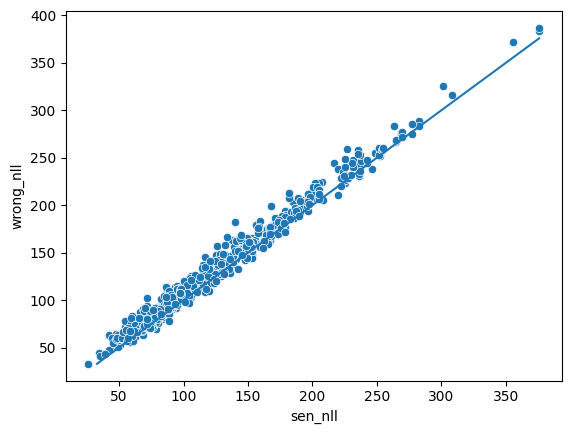

Text(0.5, 0, 'P(+) > P(-)')

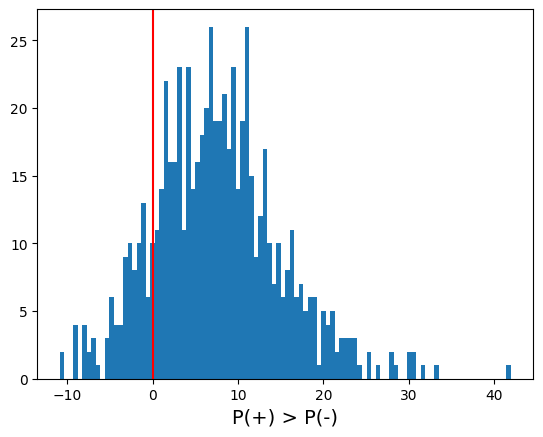

In [42]:
import seaborn as sns

sns.scatterplot(
    data=swap_df,
    x='sen_nll',
    y='wrong_nll',
)
plt.plot([min(swap_df['wrong_nll']), max(swap_df['sen_nll'])], [min(swap_df['wrong_nll']), max(swap_df['sen_nll'])])
plt.show()

plt.hist(
    swap_df.delta,
    100,
)
plt.axvline(0, color='red')
plt.xlabel("P(+) > P(-)", fontsize=14)

In [390]:
deprel = 'obj'
case = 'Acc'

sub_df = df[(df.deprel==deprel) & (df.head_pos == "VERB")]

print(f"{'treebank':<20}", "n", f"% {case} --[{deprel}]--> VERB", sep='\t')
for tb, df2 in sub_df.groupby("treebank"):
    df2 = df2[~pd.isna(df2).child_Case]
    pct = 100*Counter(df2.child_Case)[case] / sum(Counter(df2.child_Case).values())
    print(f"{tb:<20}", sum(Counter(df2.child_Case).values()), f"{pct:.1f}", sep='\t')

treebank            	n	% Acc --[obj]--> VERB
UD_Turkish-Atis     	2335	31.9
UD_Turkish-BOUN     	6103	81.0
UD_Turkish-FrameNet 	1070	56.4
UD_Turkish-GB       	1115	61.2
UD_Turkish-IMST     	3000	55.7
UD_Turkish-Kenet    	6297	41.2
UD_Turkish-PUD      	333	80.8
UD_Turkish-Penn     	4720	40.8
UD_Turkish-Tourism  	2115	27.3
UD_Turkish-TueCL    	59	57.6


In [387]:
for _, item in sub_df[sub_df.child_Case == "Acc"].iterrows():
    if len(item.sen) < 10:
        print(item.child_form, item.sent_id, item.treebank, ' '.join(item.sen), sep='\t')
        break

ulaşımını	0011.train	UD_Turkish-Atis	Şimdi bana pazartesi öğlen Houston'daki karayolu ulaşımını göster


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline


RND = 42

sub_df = df[(df.deprel=="obj") & (df.head_pos == "VERB")]

omit_feats = {"head_lemma", "child_lemma", "head_form", "child_form", "head_Number"}
omit_feats = set()
SUB_CONDITION_ON = list(set(CONDITION_ON) - omit_feats)
# SUB_CONDITION_ON = ["in_question", "under_acl", "head_VerbForm", "head_deprel"]

X = sub_df.drop(["sen", "dir"], axis=1)
X = sub_df[SUB_CONDITION_ON]
y = sub_df["dir"]

numeric_cols = [
    feat for feat in SUB_CONDITION_ON 
    if (
        "freq" in feat 
        or (feat == "num_siblings")
        or ("under" in feat)
        or "question" in feat
    )
]
categorical_cols = list(set(SUB_CONDITION_ON) - set(numeric_cols))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=RND)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        criterion="entropy", 
        random_state=RND,
        # max_depth=5,
        # min_samples_leaf=25,
        # min_impurity_decrease=0.01,
        # ccp_alpha=0.01,
    ))
])

model.fit(X_train, y_train)

print("Train acc", model.score(X_train, y_train))
print("Test acc ", model.score(X_test, y_test))

Train acc 0.9997700268302031
Test acc  0.9772413793103448


In [44]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")


RND = 42

sub_df = df[(df.deprel=="obj") & (df.head_pos == "VERB")]

omit_feats = {"head_lemma", "child_lemma", "head_form", "child_form", "head_Number"}
omit_feats = set()
SUB_CONDITION_ON = list(set(CONDITION_ON) - omit_feats)
# SUB_CONDITION_ON = ["in_question", "under_acl", "head_VerbForm", "head_deprel"]

X = sub_df.drop(["sen", "dir"], axis=1)
X = sub_df[SUB_CONDITION_ON]
y = sub_df["dir"]

numeric_cols = [
    feat for feat in SUB_CONDITION_ON 
    if (
        "freq" in feat 
        or (feat == "num_siblings")
        or ("under" in feat)
        or "question" in feat
    )
]
categorical_cols = list(set(SUB_CONDITION_ON) - set(numeric_cols))

for col in categorical_cols:
    X[col] = X[col].astype('category')
    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=RND)

model = LGBMClassifier(
    objective='multiclass' if len(y.unique()) > 2 else 'binary',
    max_depth=5,
    min_child_samples=25,        # similar to min_samples_leaf
    min_split_gain=0.01,          # similar to min_impurity_decrease
    random_state=RND,
    n_estimators=3,              # number of trees
    verbose=-1,
)

# Fit the model, passing categorical features directly
model.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)

# Evaluate
print("Train acc", model.score(X_train, y_train))
print("Test acc ", model.score(X_test, y_test))

Train acc 0.9617477960904561
Test acc  0.9779310344827586


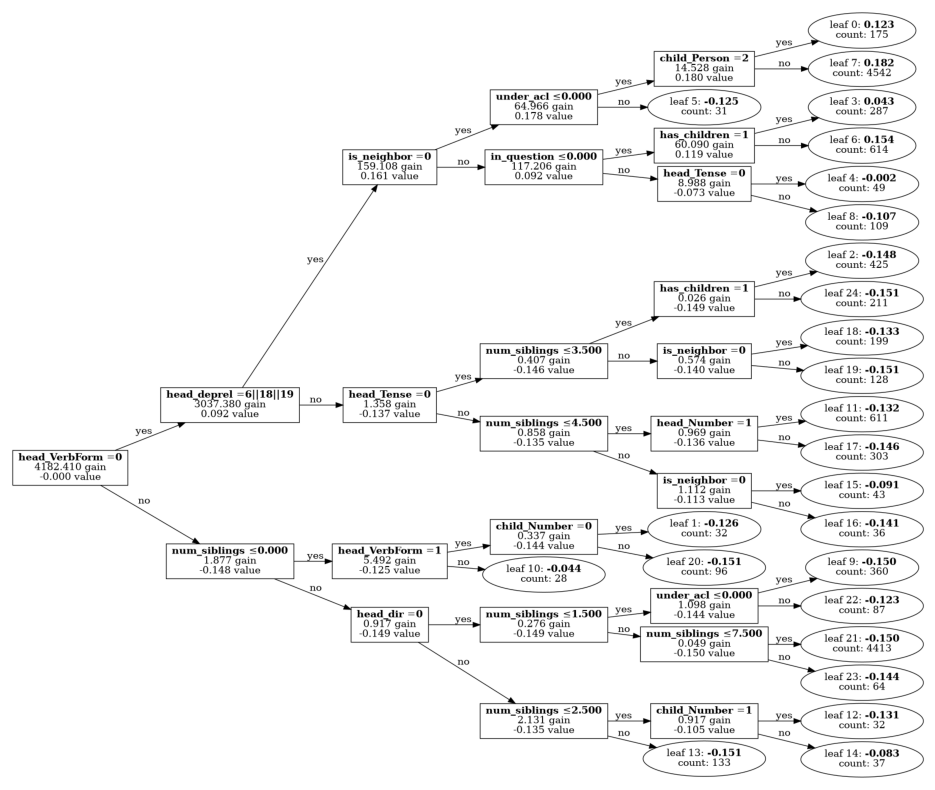

In [46]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# Create a booster object from the fitted model
booster = model.booster_

# Plot the first tree (index 0)
ax = lgb.plot_tree(
    booster, 
    tree_index=2, 
    figsize=(20, 10), 
    show_info=['split_gain', 'internal_value', 'leaf_count', 'entropy']
)
plt.show()

In [17]:
import matplotlib.pyplot as plt
import lightgbm as lgb
import numpy as np
import pandas as pd

def plot_lgb_tree_pretty(model, X_train, tree_index=0):
    """
    Print a LightGBM tree with categorical labels instead of integer codes.
    """
    booster = model.booster_
    tree = booster.dump_model()['tree_info'][tree_index]['tree_structure']
    feature_names = X_train.columns.tolist()

    # Build mapping for categorical columns
    cat_mappings = {}
    for col in X_train.select_dtypes(['category']).columns:
        cat_mappings[col] = dict(enumerate(X_train[col].cat.categories))

    def recurse(node, depth=0):
        indent = "  " * depth
        # Internal node
        if 'split_index' in node:
            feature = feature_names[node['split_feature']]
            threshold = node['threshold']
            split_cat = None
            if node.get('decision_type') == '==':
                if feature in cat_mappings:
                    codes = [int(x) for x in str(threshold).split('||')]
                    labels = [cat_mappings[feature][c] for c in codes]
                    split_cat = labels
            if split_cat:
                print(f"{indent}[{feature} in {split_cat}]")
            else:
                print(f"{indent}[{feature} <= {threshold:.3f}]")
            recurse(node['left_child'], depth+1)
            recurse(node['right_child'], depth+1)
        # Leaf node
        else:
            samples = node.get('leaf_count', node.get('internal_count', 'N/A'))
            print(f"{indent}Leaf: value={node['leaf_value']:.3f}, samples={samples}")

    recurse(tree)


# -------------------------------
# Example usage

# Ensure categorical columns are of dtype 'category'
for col in categorical_cols:
    X_train.loc[:, col] = X_train[col].astype('category')

# Fit LightGBM
model = lgb.LGBMClassifier(max_depth=5, min_child_samples=25, min_split_gain=0.01, random_state=RND)
model.fit(X_train, y_train, categorical_feature=categorical_cols)

# Pretty tree plot in console
plot_lgb_tree_pretty(model, X_train, tree_index=0)

[head_VerbForm in ['Fin']]
  [head_deprel in ['conj', 'parataxis', 'root']]
    [under_acl <= 0.000]
      [in_question <= 0.000]
        Leaf: value=-0.133, samples=5239
        Leaf: value=-0.214, samples=507
      Leaf: value=-0.500, samples=61
    [under_acl <= 0.000]
      Leaf: value=-0.507, samples=760
      [in_question <= 0.000]
        Leaf: value=-0.511, samples=1127
        Leaf: value=-0.521, samples=69
  [head_VerbForm in ['Inf']]
    Leaf: value=-0.519, samples=3814
    [under_acl <= 0.000]
      [in_question <= 0.000]
        Leaf: value=-0.516, samples=1105
        Leaf: value=-0.521, samples=47
      Leaf: value=-0.509, samples=316


/tmp/ipykernel_53613/3435164525.py:55: RuntimeWarning: invalid value encountered in divide
  ratios = np.zeros((num_langs, len(deprels))) / 0


Text(0.5, 1.0, 'Word order entropy')

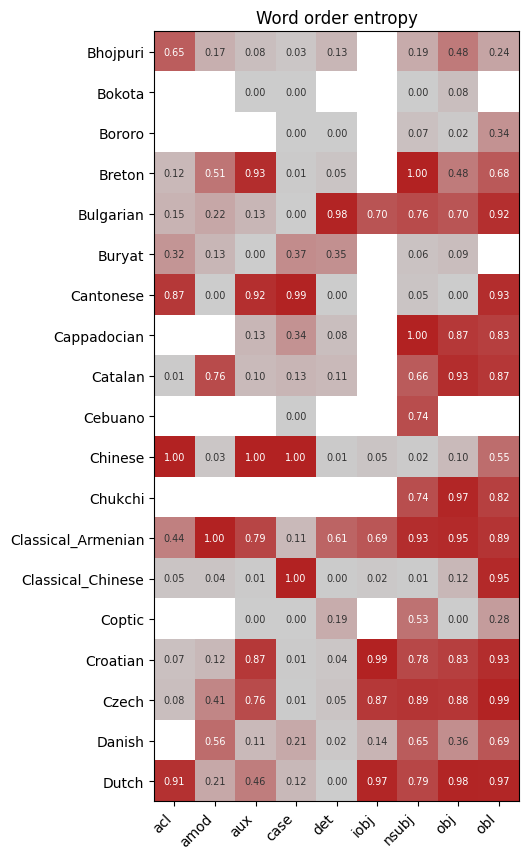

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


def order_entropy(n_ab, n_ba):
    """
    Compute Shannon entropy (in bits) for word order frequencies.
    
    Args:
        n_ab (int): Count of A>B order
        n_ba (int): Count of B>A order
    
    Returns:
        float: Entropy in bits
    """
    total = n_ab + n_ba
    if total == 0:
        return 0.0  # no data
    
    p_ab = n_ab / total
    p_ba = n_ba / total
    
    # avoid log(0) issues
    def safe_term(p):
        return -p * math.log2(p) if p > 0 else 0.0
    
    return safe_term(p_ab) + safe_term(p_ba)

# Define your two colors
color1 = "0.8"  # blue
color2 = "firebrick"  # orange

# Create a custom colormap
cmap = LinearSegmentedColormap.from_list("custom_cmap", [color1, color2])

sub_langs = list(all_deprel_dirs.keys())[1:40]
num_langs = len(sub_langs)
min_count = 100

deprels = ["acl", "amod", "aux", "case", "det", "iobj", "nsubj", "obj", "obl"]

# contains_deprel = ["nsubj"]
# contains_head_pos = ["VERB"]
# deprels = set()
# for deprel_directions in all_deprel_dirs.values():
#     for deprel, counts in deprel_directions.items():
#         if (sum(counts) > min_count) and deprel[0] in contains_deprel and deprel[2] in contains_head_pos:
#             deprels.add(deprel)

# deprels = sorted(deprels)

ratios = np.zeros((num_langs, len(deprels))) / 0

# plt.figure(figsize=(20, 10))
plt.figure(figsize=(5, 10))

for i, lang in enumerate(sub_langs):
    for j, deprel in enumerate(deprels):
        if sum(all_deprel_dirs[lang][deprel]) > min_count:
            # ratios[i, j] = all_deprel_dirs[lang][deprel][0] / sum(all_deprel_dirs[lang][deprel])
            ratios[i, j] = order_entropy(all_deprel_dirs[lang][deprel][0], all_deprel_dirs[lang][deprel][1])
            
            cell_text = f"{ratios[i, j]:.2f}"
            plt.text(
                j,i, 
                cell_text,
                ha="center", 
                va="center", 
                color=("w" if (ratios[i, j] > 0.5) else "0.2"), 
                fontsize=7
            )

plt.imshow(
    ratios,
    clim=(0,1),
    cmap=cmap,
)
plt.xticks(range(len(deprels)), deprels, rotation=45)
plt.yticks(range(num_langs), sub_langs)

for label in plt.gca().get_xticklabels():
    label.set_ha("right")   # left, center, or right

# plt.colorbar(label="child<head entropy")
plt.title("Word order entropy")